# 1. 선형회귀

## 1-1. 단순 선형 회귀 분석
$
y = wx + b
$    

![img](https://blog.kakaocdn.net/dn/dVmgUI/btrs8At6HLP/3QZU2lVIv4jUJWvmQucWyk/img.gif)

## 1-2. 다중 선형 회귀 분석
$
y = w_1x_1 + w_2x_2 + ... + w_nx_n + b
$

>독립변수가 여러개일때 사용 선형회귀  
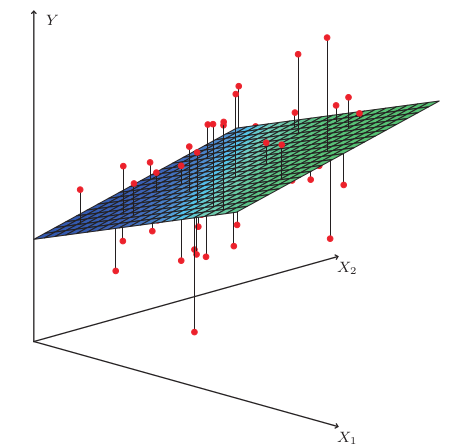

# 2. 정규화
> 모델을 학습할 때는 비용(=오류=손실)을 최소화 하는 방향으로 진행 됨.  
> 이 비용, 손실이 얼마나 있는지 나타내는 걸 '손실함수', '비용함수'

> 근데 단순히 이 손실함수를 작아지는 쪽으로 학습하면 특정 가중치(w)값이 커지면서 결과가 나빠지므로 cost function을 바꿔주는 역할을 하는게 정규화임.

## 2-1. L1 Regulariztion (절댓값)
- 가중치의 합을 더한 값에 learning rate(학습률) $\lambda$ 를 곱하여 오차에 더한다.
- L2 Norm은 각각의 벡터에 대해 항상 Unique한 값을 내지만, L1 Norm은 경우에 따라 특정 Feature 없이도 같은 값을 낼 수 있습니다. 즉, L1 Regularization은 Feature selection이 가능합니다.
- 이러한 특징 때문에 L1은 Sparse dataset에 적합합니다.

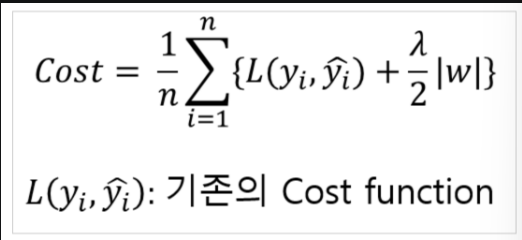

## 2-2. L2 REgularization (제곱)
- 각 가중치 제곱의 합에 learning rate(학습률) $\lambda$ 를 곱한다.
- learning rate(학습률) $\lambda$ 를 크게 하면 가중치가 더 많이 감소되고, $\lambda$ 를 작게 하면 가중치가 증가한다

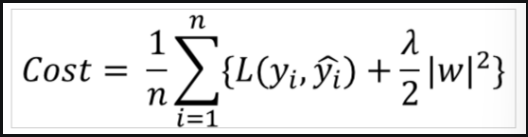

# 3. 회귀의 선형 모델

## 3-1. LinearRegression
> 최소제곱법(Ordinary Least Squares)을 활용.    
> 실제값에서 예측값을 뺀 차이의 제곱에 합

$$
\sum{(y_i - f(x_i))^2}
$$

> 아무 규제 없이 사용하니까 오버피팅되면서 결과가 개망함.따라서 l1,l2의 제약을 사용하여 오버피팅을 막아보자.   
 
> (제약이므로 테스트 평가지표 점수가 낮게 나올수도 있음. 규제를 하는 이유는 점수를 올리기 위함이 아니라 오버피팅을 막기위함임을 기억하자.)

## 3-2. Ridge with L2
> 선형회귀에 L2 규제 적용

>alpha값을 이용하여 규제의 정도를 조절 가능함.
- alpha 값을 낮추면 규제의 효과가 없어져 과대적합이 될 가능성이 높아집니다.   
- alpha 값을 높이면 훈련 세트의 성능은 나빠지지만 일반화에는 도움을 줄 수 있다.

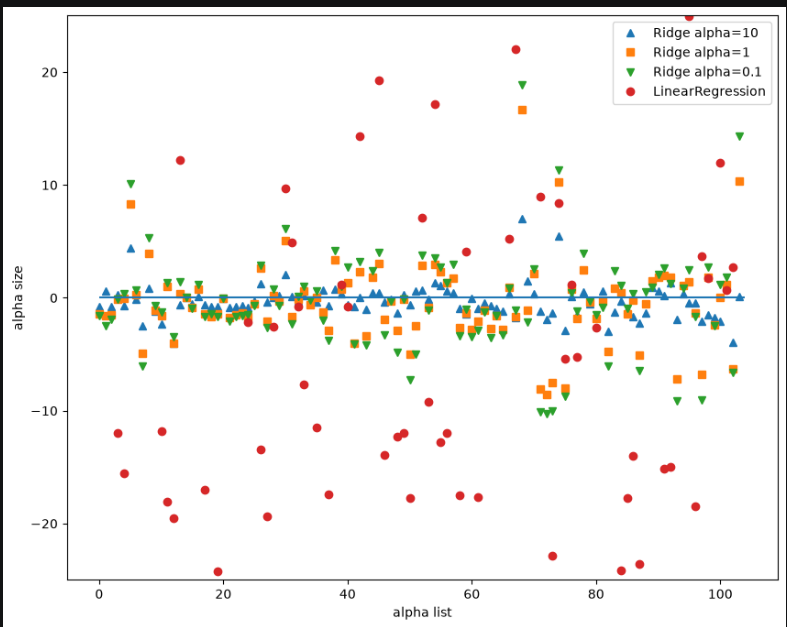  
> 위의 그래프에서 alpha size, alpha list가 먼지 알아야됨.  
> 이 그래프만 이해하면됨. x축이 실제 커럼의 개수랑 똑같고(weight개수는 feaure개수와 같으니까),점하나하나가 x와 곱셈연산을 할 weight인거임. weight와 x 둘중 >하나라도 0이면 선형회귀는 0이지 중간에 선그어잇는게 0임. weight가 0이면 y를 예측하는데 feauture를 반영 못시킴.   

>즉, 선 0에 가까워질수록 실제 x는 y를 추론하는데 영향을 적게 끼친다는 소리임. 어떤 feature가 x에 영향을 많이 끼치는지 모르잖아? 모델은 영향을 더 많이 미치는 >feature 거기에 더 weight를 키우겠지? 그런식으로 학습하는거임.

>alpha는 뭐냐? 빨간색은 alpha값 반영낭한 선형회귀모델이고,,, 우리가 저 알파값을 바꿔가면서 선형회귀모델을 바꿔ㅏ는거임. 저 빨간색 점을 기준으로 alpha를 넣으면 >어떻게 변하는지 보자. 빨간색에 비해 파란색은 0선에 가깝네? 아 제약조건 알파 10을 주니까 대부분의 feature를 추론할때 무시하고있네?라는것을 알수있음.
>그럼 뭐가 좋은거임? 빨간색들과 파란색들의 사이 어딘가가 우리가 원하는 거겠지? 실제 나온거보니까 그게 alpha = 0.35였음.
>제약을 너무거니까(알파가 너무크니까) 모델이 공부안한다고한거임(가중치를 거의 안줬음 feature들에). 그러므로 당근과 채찍을 줘야함.


Ridge에서 alpha값이 클 수록 각각의 계수 크기가 작아지는 경향을 볼 수 있습니다. 따라서 L2 규제가 강해진다고 할 수 있으며, 이는 과적합이 될 가능성이 낮아진다는 뜻입니다.    
  
하지만 aplha값을 아무리 높이더라도 Ridge의 계수크기가 0이 되지는 않습니다.

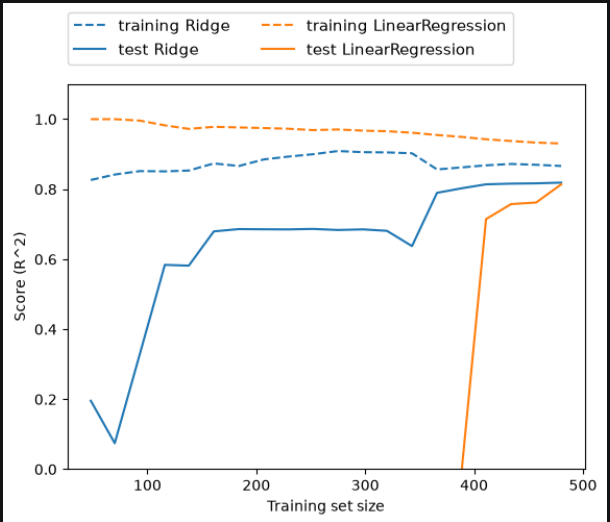  

> 위 그래프 때문에 많은 회사들이 선형회귀보다 제약조건이 들어간 선형회귀를 쓰는거임. 그럼 위 그래프는 뭘까? y축은 r스퀘어 점수이고 x축은 학습데이터 셋 크기임.

> 위 그래프를 해석해보면, training에선 선형회귀모델이 ridge보다 계속높음. 제약조건이 없으니까!!! 하이퍼파라미터 튜닝, 즉 제약조건을 거는건 공부를 잘하게 하는게 아님. 공부를 방해하는거임.스코어를 올리는 테크닉이 아님. 오버피팅을 못하게 방해하는거임.

> 근데 그렇게 되면 나중에 test 때 점수가 낮아짐. 학습 데이터를 완벽히 예측한다는건 그만큼 test데이터에 오차가 커짐. 그래서 우리가 제약조건을 거는거임.

> 위 그래프 보면 알수있듯이. 학습데이터에선 ridge걸면 무조건 손해인데, 평가데이터에선 ridge걸린게 무조건 이득이잖아 그거때문에 우리가 ridge즉 하이퍼파라미터 튜닝을 하는거임.

>제약조건 걸면 장점이 하나더 있음. 바로 상대적으로 적은 데이터에서도 스코어가 올라감. 

## 3-3. Lasso with L1
> L1 규제를 사용하면, 실제로 일부 피쳐들의 계수(weight)가 0이 된다. 이 말은 모델에서 완전히 제외되는 특성(피쳐)이 생긴다는 뜻이다.    
> 일부 계수를 0으로 만들면 모델을 이해하기 쉬워지고 이 모델의 가장 중요한 특성이 무엇인지 드러내준다.  
  
alpha값을 줄이면 가장 낮은 오차를 찾아가는 반복횟수(max_iter)가 늘어나야 합니다.

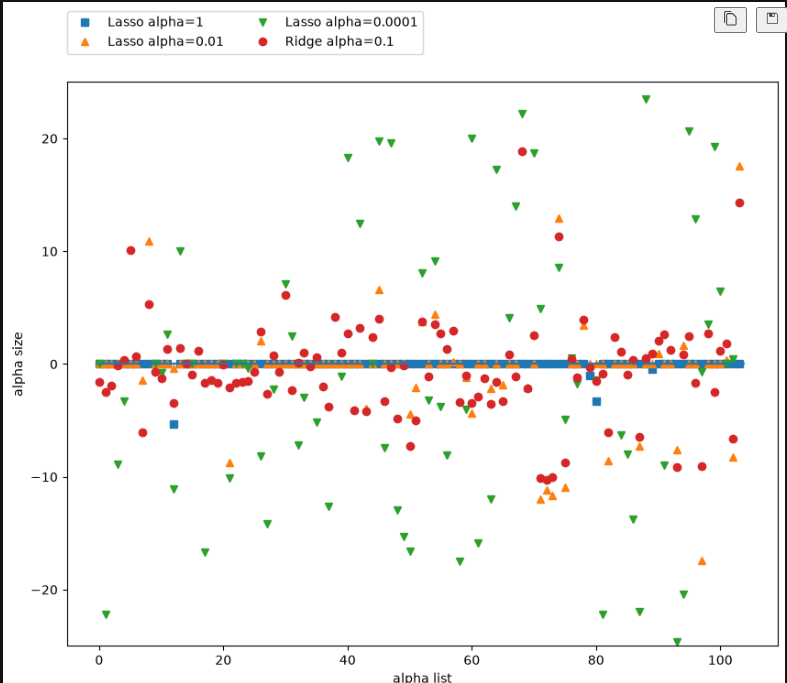

## 3-4. ElasticNet
> 선형회귀에 L1규제, L2규제를 동시에 적용한 모델이다.
- 주요 파라미터
  - alpha: 규제 계수
  - l1_ratio(default=0.5)
    - 0이면, L2 규제만
    - 1이면, L1 규제만
    - 0 < l1_ratio < 1이면, 혼합